In [1]:
import sys
print(sys.executable)

c:\Users\ycode\Desktop\2nd_YouCode\briefs\Prediction_Prix_Immobilier\venv\Scripts\python.exe


In [2]:
# ===== Imports =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ===== Configuration =====
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ===== Chemins =====
DATA_PATH = '../data/raw/House_Prices_original.csv'

# ===== Versions =====
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"seaborn : {sns.__version__}")

pandas  : 3.0.6
numpy   : 2.5.3
seaborn : 0.13.2


In [3]:
# ===== Chargement =====
df = pd.read_csv(DATA_PATH)

print(f"Train : {df.shape}")
print(f"Id min/max : {df['Id'].min()} / {df['Id'].max()}")
print(f"SalePrice moyenne : {df['SalePrice'].mean():,.0f}")


Train : (2919, 81)
Id min/max : 1 / 2919
SalePrice moyenne : 180,053


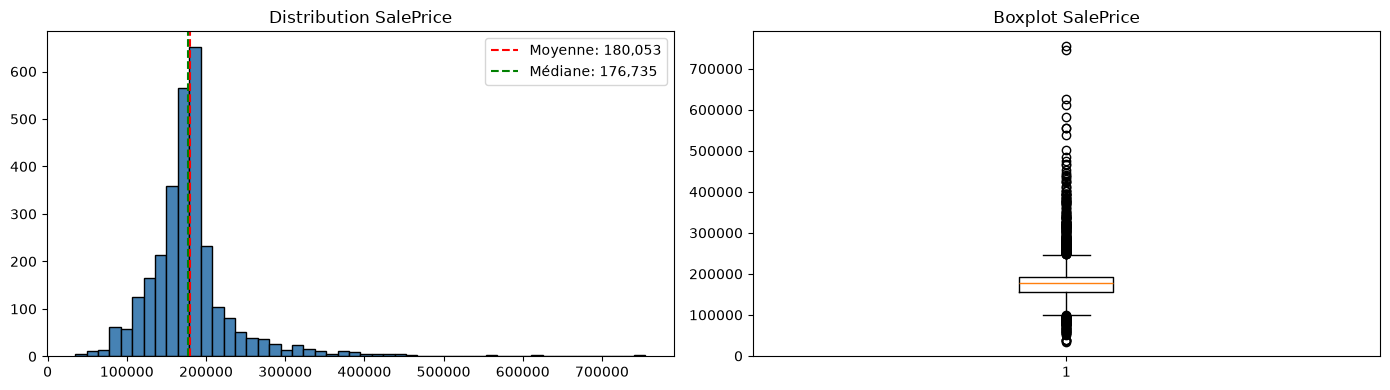

Skewness : 2.549


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--', label=f'Médiane: {df["SalePrice"].median():,.0f}')
axes[0].set_title('Distribution SalePrice'); axes[0].legend()
axes[1].boxplot(df['SalePrice'], vert=True); axes[1].set_title('Boxplot SalePrice')
plt.tight_layout(); plt.show()
print(f"Skewness : {df['SalePrice'].skew():.3f}")

### 📈 Interprétation — Distribution de `SalePrice`

La distribution de `SalePrice` est fortement asymétrique à droite, avec une skewness d'environ 2,55. La moyenne est supérieure à la médiane, car quelques biens très chers tirent la distribution vers le haut.

👉 Impact pour le modèle : une transformation logarithmique de la cible, par exemple `log1p(SalePrice)`, peut réduire l'asymétrie et améliorer la qualité des prédictions.

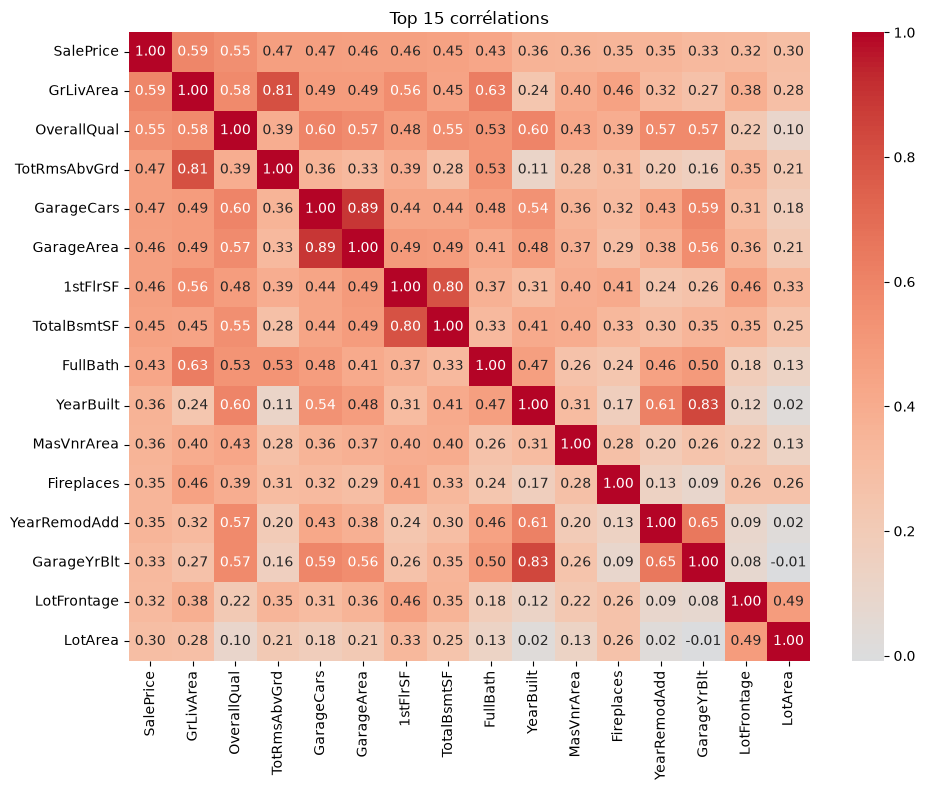

SalePrice      1.00
GrLivArea      0.59
OverallQual    0.55
TotRmsAbvGrd   0.47
GarageCars     0.47
GarageArea     0.46
Name: SalePrice, dtype: float64


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()['SalePrice'].sort_values(ascending=False)
top15 = corr.head(16).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[top15].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Top 15 corrélations'); plt.tight_layout(); plt.show()
print(corr.head(6))

### 📈 Interprétation — Corrélations avec `SalePrice`

Les variables les plus liées au prix sont `GrLivArea` (corrélation de 0,59) et `OverallQual` (0,55), suivies notamment par le nombre de pièces et les caractéristiques du garage. Ces corrélations indiquent que la surface habitable et la qualité générale sont des signaux importants, même si elles ne suffisent pas à expliquer seules le prix.

👉 Impact pour le modèle : `GrLivArea` et `OverallQual` doivent être conservées comme variables prioritaires, avec une attention particulière aux relations non linéaires.

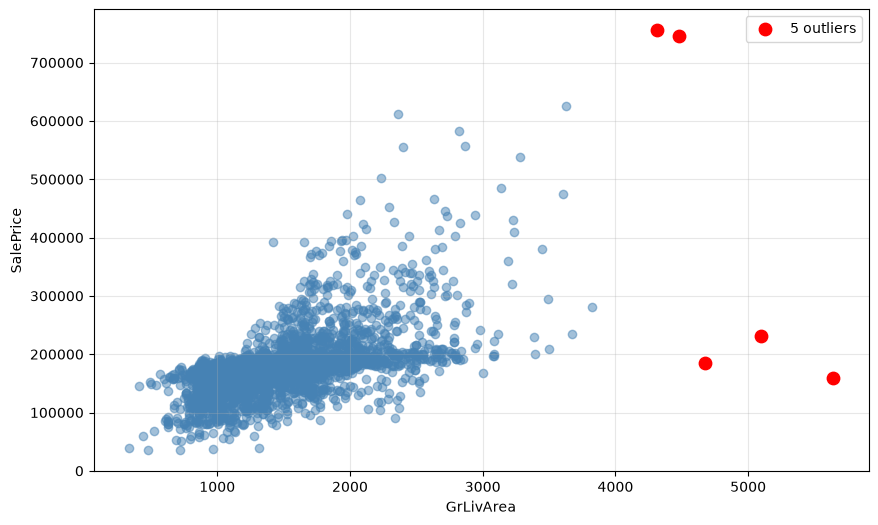

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='steelblue')
mask = df['GrLivArea'] > 4000
plt.scatter(df.loc[mask, 'GrLivArea'], df.loc[mask, 'SalePrice'], color='red', s=80, label=f'{mask.sum()} outliers')
plt.xlabel('GrLivArea'); plt.ylabel('SalePrice'); plt.legend(); plt.grid(alpha=0.3); plt.show()

### 📈 Interprétation — `GrLivArea` et `SalePrice`

Le nuage de points confirme une relation globalement positive : les maisons disposant d'une plus grande surface habitable ont tendance à être plus chères. Quelques observations très éloignées, notamment parmi les surfaces supérieures à 4 000 pieds carrés, peuvent influencer fortement l'apprentissage.

👉 Impact pour le modèle : il faut contrôler les valeurs atypiques de `GrLivArea` et vérifier leur cohérence avant l'entraînement.

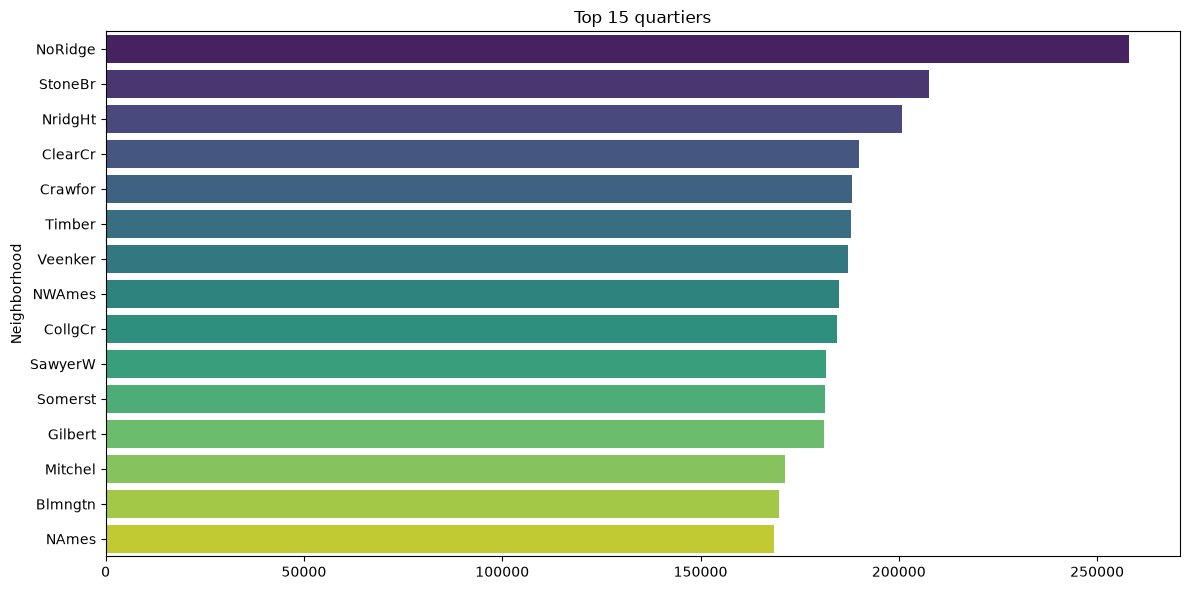

Neighborhood
NoRidge   258,000.00
StoneBr   207,500.00
NridgHt   200,685.04
ClearCr   190,027.32
Crawfor   188,206.28
Name: SalePrice, dtype: float64


In [7]:
top_neigh = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_neigh.values, y=top_neigh.index, palette='viridis')
plt.title('Top 15 quartiers'); plt.tight_layout(); plt.show()
print(top_neigh.head())


### 📈 Interprétation — Prix par `Neighborhood`

Les quartiers `NoRidge`, `StoneBr` et `NridgHt` affichent les prix médians les plus élevés, ce qui révèle un effet géographique important. Le quartier constitue donc une information déterminante, mais la médiane doit être interprétée avec le nombre d'observations disponible pour chaque quartier.

👉 Impact pour le modèle : la variable `Neighborhood` doit être encodée et conservée, car elle capture une partie importante de la valeur locale des biens.

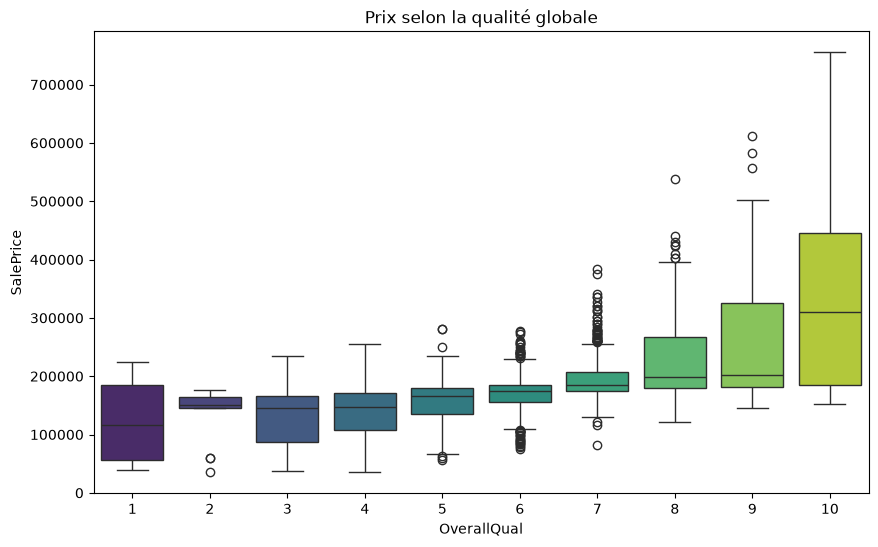

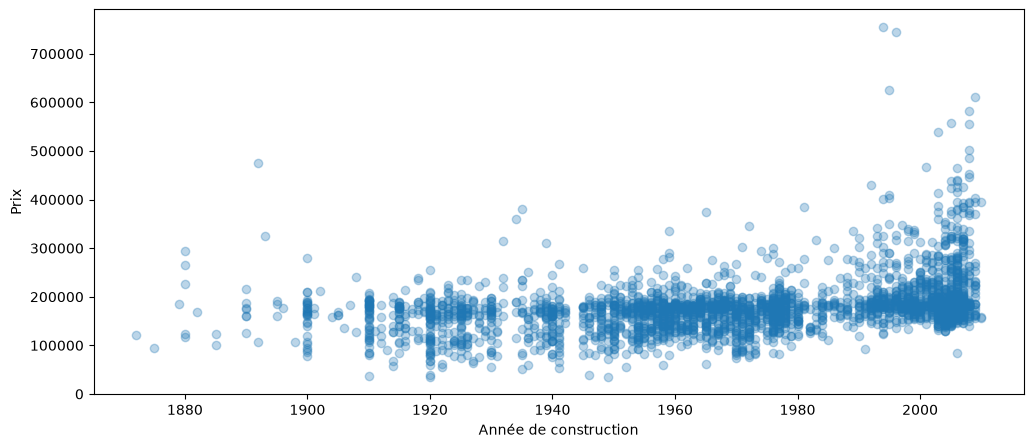

<Axes: xlabel='YrSold'>

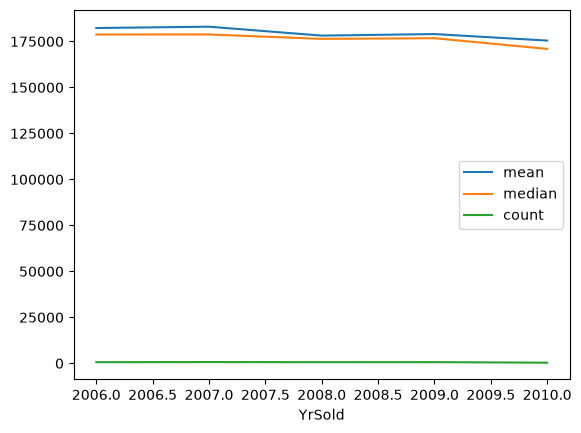

In [8]:
# 1. OverallQual vs SalePrice
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='viridis')
plt.title('Prix selon la qualité globale')
plt.show()

# 2. YearBuilt vs SalePrice
plt.figure(figsize=(12, 5))
plt.scatter(df['YearBuilt'], df['SalePrice'], alpha=0.3)
plt.xlabel('Année de construction')
plt.ylabel('Prix')
plt.show()

# 3. Année de vente vs nombre de ventes
df.groupby('YrSold')['SalePrice'].agg(['mean', 'median', 'count']).plot()

### 📈 Interprétation — `OverallQual` et `SalePrice`

Le boxplot montre une progression nette du prix médian lorsque la qualité globale augmente. La dispersion reste importante dans certaines catégories, ce qui signifie que d'autres facteurs comme la surface, le quartier et l'état du bien interviennent également.

👉 Impact pour le modèle : `OverallQual` est une variable centrale et peut être traitée comme une variable ordinale plutôt que comme une simple catégorie nominale.

### 📈 Interprétation — `YearBuilt` et `SalePrice`

Le graphique suggère une tendance générale à la hausse : les maisons les plus récentes sont souvent plus chères. La relation reste toutefois dispersée, car la qualité, la surface et le quartier peuvent compenser l'effet de l'âge du bâtiment.

👉 Impact pour le modèle : `YearBuilt` doit être conservée et peut être complétée par une variable d'âge au moment de la vente, comme `Age`.

### 📈 Interprétation — `YrSold` et les ventes

Le nombre de ventes et les prix moyens ou médians peuvent varier selon l'année de vente, mais cette variable temporelle décrit surtout le contexte du marché observé. L'effet de `YrSold` doit être interprété avec prudence, car la période couverte reste courte.

👉 Impact pour le modèle : `YrSold` peut être conservée comme variable temporelle, mais elle doit compléter plutôt que remplacer les caractéristiques intrinsèques du bien.